# 03 — BESS Dispatch Optimizer (CVXPY LP)

**Goal:** Build a perfect-foresight energy arbitrage optimizer for a 100MW/400MWh battery.

**Method:** Linear program (LP) — maximize revenue from price spreads subject to physical constraints (SOC limits, power limits, round-trip efficiency, energy balance).

**Validation:** Synthetic price tests + 1-week real ERCOT data check.

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import cvxpy as cp
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

print(f'CVXPY version: {cp.__version__}')

CVXPY version: 1.8.1


## Asset Configuration

In [2]:
# 100MW / 400MWh BESS (4-hour duration, LFP typical)
POWER_MW = 100        # MW nameplate
ENERGY_MWH = 400      # MWh usable capacity
RTE = 0.87            # Round-trip efficiency (LFP)
SOC_MIN = 0.05        # 5% min SOC
SOC_MAX = 0.95        # 95% max SOC
SOC_INIT = 0.50       # Start at 50%
DT = 1.0              # Hourly intervals (matches GCS data)

# Derived
ETA_CH = np.sqrt(RTE)   # Charge efficiency ~0.933
ETA_DIS = np.sqrt(RTE)  # Discharge efficiency ~0.933
SOC_MIN_MWH = SOC_MIN * ENERGY_MWH  # 20 MWh
SOC_MAX_MWH = SOC_MAX * ENERGY_MWH  # 380 MWh
SOC_INIT_MWH = SOC_INIT * ENERGY_MWH  # 200 MWh

print(f'Asset: {POWER_MW} MW / {ENERGY_MWH} MWh ({ENERGY_MWH/POWER_MW:.0f}h duration)')
print(f'RTE: {RTE:.0%} → η_ch = η_dis = {ETA_CH:.4f}')
print(f'SOC bounds: [{SOC_MIN_MWH:.0f}, {SOC_MAX_MWH:.0f}] MWh')
print(f'Usable energy: {SOC_MAX_MWH - SOC_MIN_MWH:.0f} MWh')

Asset: 100 MW / 400 MWh (4h duration)
RTE: 87% → η_ch = η_dis = 0.9327
SOC bounds: [20, 380] MWh
Usable energy: 360 MWh


## Optimizer Function

**LP Formulation:**
- **Variables:** `p_ch[t]`, `p_dis[t]` ≥ 0, `soc[t]`
- **Objective:** maximize Σ price[t] × dt × (p_dis[t] − p_ch[t])
- **Constraints:**
  - `soc[t+1] = soc[t] + η_ch × p_ch[t] × dt − (1/η_dis) × p_dis[t] × dt`
  - `0 ≤ p_ch[t] ≤ P_max`, `0 ≤ p_dis[t] ≤ P_max`
  - `soc_min ≤ soc[t] ≤ soc_max`
  - `soc[0] = soc_init`, `soc[T] = soc_init` (cyclic)

In [3]:
def optimize_dispatch(prices, dt=1.0, power_mw=100, energy_mwh=400,
                      rte=0.87, soc_min=0.05, soc_max=0.95,
                      soc_init=0.50, soc_final=0.50):
    """
    Perfect-foresight BESS energy arbitrage optimizer.
    
    Args:
        prices: array-like of $/MWh prices (hourly)
        dt: time step in hours
        power_mw: max charge/discharge power (MW)
        energy_mwh: total energy capacity (MWh)
        rte: round-trip efficiency
        soc_min/max: SOC bounds as fraction of capacity
        soc_init/final: initial and final SOC as fraction
    
    Returns:
        dict with p_charge, p_discharge, soc, revenue, status
    """
    prices = np.asarray(prices, dtype=float)
    T = len(prices)
    
    eta_ch = np.sqrt(rte)
    eta_dis = np.sqrt(rte)
    soc_min_mwh = soc_min * energy_mwh
    soc_max_mwh = soc_max * energy_mwh
    soc_init_mwh = soc_init * energy_mwh
    soc_final_mwh = soc_final * energy_mwh
    
    # Decision variables
    p_ch = cp.Variable(T, nonneg=True)    # Charge power (MW)
    p_dis = cp.Variable(T, nonneg=True)   # Discharge power (MW)
    soc = cp.Variable(T + 1, nonneg=True) # State of charge (MWh)
    
    # Objective: maximize revenue
    revenue = prices @ (p_dis - p_ch) * dt
    objective = cp.Maximize(revenue)
    
    # Constraints
    constraints = [
        # Power limits
        p_ch <= power_mw,
        p_dis <= power_mw,
        # SOC dynamics
        soc[1:] == soc[:-1] + eta_ch * p_ch * dt - (1.0 / eta_dis) * p_dis * dt,
        # SOC bounds
        soc >= soc_min_mwh,
        soc <= soc_max_mwh,
        # Boundary conditions
        soc[0] == soc_init_mwh,
        soc[T] == soc_final_mwh,
    ]
    
    # Solve
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.CLARABEL, verbose=False)
    
    if prob.status not in ['optimal', 'optimal_inaccurate']:
        return {'status': prob.status, 'revenue': 0}
    
    return {
        'p_charge': p_ch.value,
        'p_discharge': p_dis.value,
        'soc': soc.value,
        'revenue': prob.value,
        'status': prob.status,
        'objective': prob.value,
    }

print('optimize_dispatch() defined')

optimize_dispatch() defined


## Sanity Tests

In [4]:
# Test 1: Synthetic prices — should charge low, discharge high
print('=== Test 1: Synthetic [10, 50, 10, 50] ===')
result = optimize_dispatch([10, 50, 10, 50], power_mw=100, energy_mwh=400)
print(f'Status: {result["status"]}')
print(f'Revenue: ${result["revenue"]:,.2f}')
print(f'Charge:    {np.round(result["p_charge"], 1)}')
print(f'Discharge: {np.round(result["p_discharge"], 1)}')
print(f'SOC:       {np.round(result["soc"], 1)}')
assert result['status'] == 'optimal'
assert result['revenue'] > 0
# Should charge at t=0,2 (price=10), discharge at t=1,3 (price=50)
assert result['p_charge'][0] > result['p_charge'][1]
assert result['p_discharge'][1] > result['p_discharge'][0]
print('✓ Passed\n')

# Test 2: Flat prices — no arbitrage opportunity
print('=== Test 2: Flat prices [30, 30, 30, 30] ===')
result2 = optimize_dispatch([30, 30, 30, 30])
print(f'Revenue: ${result2["revenue"]:,.2f}')
assert abs(result2['revenue']) < 1.0  # ~$0 revenue
print('✓ Passed\n')

# Test 3: Revenue >= 0 (optimizer won't lose money)
print('=== Test 3: Random prices — revenue >= 0 ===')
np.random.seed(42)
random_prices = np.random.uniform(10, 100, 168)  # 1 week
result3 = optimize_dispatch(random_prices)
print(f'Revenue: ${result3["revenue"]:,.2f}')
assert result3['revenue'] >= -0.01
print('✓ Passed\n')

# Test 4: SOC stays in bounds
print('=== Test 4: SOC bounds ===')
soc = result3['soc']
print(f'SOC range: [{soc.min():.1f}, {soc.max():.1f}] MWh')
assert soc.min() >= SOC_MIN * ENERGY_MWH - 0.1
assert soc.max() <= SOC_MAX * ENERGY_MWH + 0.1
print('✓ Passed\n')

# Test 5: Higher RTE → weakly higher revenue
print('=== Test 5: Higher RTE → more revenue ===')
rev_low = optimize_dispatch(random_prices, rte=0.80)['revenue']
rev_high = optimize_dispatch(random_prices, rte=0.95)['revenue']
print(f'RTE 80%: ${rev_low:,.2f}, RTE 95%: ${rev_high:,.2f}')
assert rev_high >= rev_low - 0.01
print('✓ Passed\n')

print('All sanity tests passed!')

=== Test 1: Synthetic [10, 50, 10, 50] ===
Status: optimal
Revenue: $6,700.00
Charge:    [100.   0. 100.   0.]
Discharge: [ 0. 94.  0. 80.]
SOC:       [200.  293.3 192.5 285.8 200. ]
✓ Passed

=== Test 2: Flat prices [30, 30, 30, 30] ===
Revenue: $-0.00
✓ Passed

=== Test 3: Random prices — revenue >= 0 ===
Revenue: $307,577.76
✓ Passed

=== Test 4: SOC bounds ===
SOC range: [20.0, 380.0] MWh
✓ Passed

=== Test 5: Higher RTE → more revenue ===
RTE 80%: $274,825.48, RTE 95%: $343,208.52
✓ Passed

All sanity tests passed!


## Quick Test on Real ERCOT Data (1 week)

In [5]:
# Load 1 week of HB_HOUSTON RT prices
PRICES_DIR = os.path.join(os.pardir, 'data', 'prices')
houston = pd.read_parquet(os.path.join(PRICES_DIR, 'HB_HOUSTON_rt_hourly.parquet'))

# Pick a volatile summer week
week = houston['2025-07-14':'2025-07-20']['price'].dropna()
if len(week) < 24:
    # Fallback to 2024 if 2025 summer not available
    week = houston['2024-07-15':'2024-07-21']['price'].dropna()

print(f'Test week: {week.index[0].date()} to {week.index[-1].date()} ({len(week)} hours)')
print(f'Price range: ${week.min():.2f} to ${week.max():.2f}')

result_week = optimize_dispatch(week.values)
print(f'\nRevenue: ${result_week["revenue"]:,.2f}')
print(f'Status: {result_week["status"]}')

Test week: 2025-07-14 to 2025-07-20 (168 hours)
Price range: $9.19 to $61.94

Revenue: $54,566.88
Status: optimal


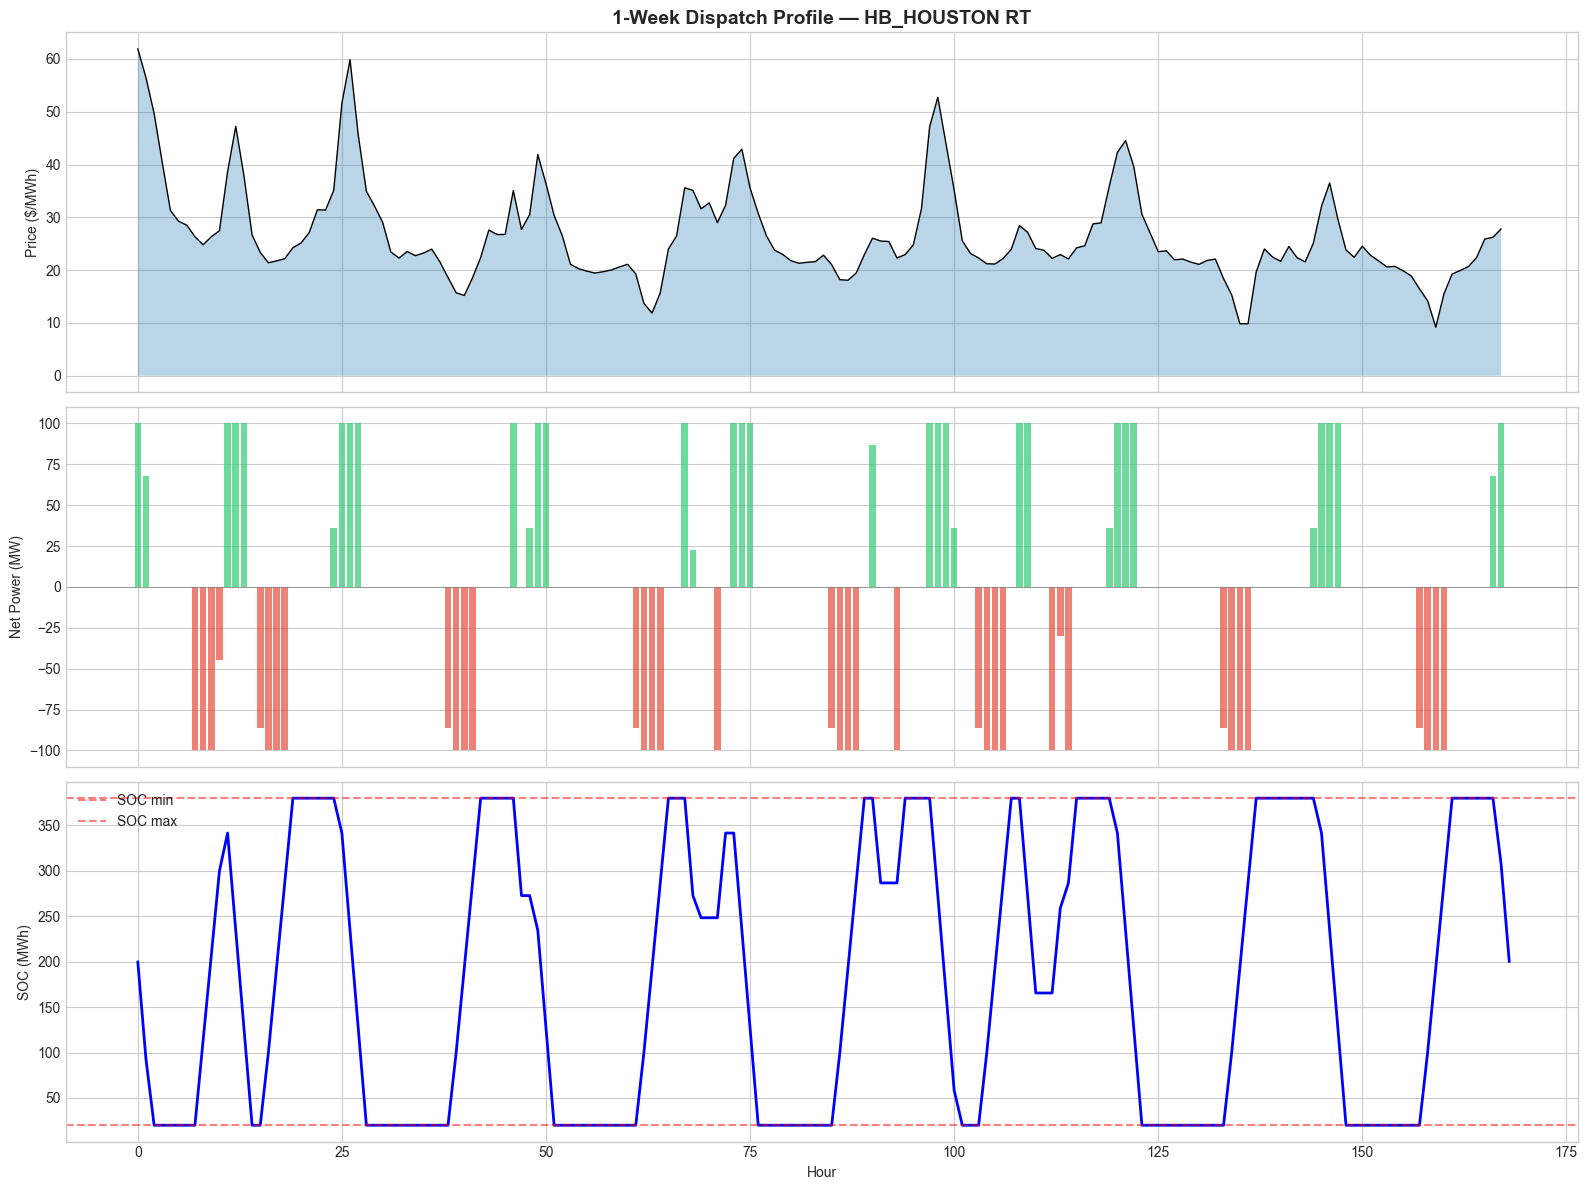


Max charge: 100.0 MW, Max discharge: 100.0 MW
SOC range: [20.0, 380.0] MWh
Full cycles: 7.6


In [6]:
# Visualize the dispatch
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

hours = range(len(week))
p_ch = result_week['p_charge']
p_dis = result_week['p_discharge']
soc = result_week['soc']

# Panel 1: Prices
axes[0].plot(hours, week.values, 'k-', linewidth=1)
axes[0].fill_between(hours, week.values, alpha=0.3)
axes[0].set_ylabel('Price ($/MWh)')
axes[0].set_title('1-Week Dispatch Profile — HB_HOUSTON RT', fontsize=14, fontweight='bold')

# Panel 2: Power (charge negative, discharge positive)
net_power = p_dis - p_ch
axes[1].bar(hours, net_power, color=['#2ecc71' if x > 0 else '#e74c3c' for x in net_power], alpha=0.7)
axes[1].axhline(y=0, color='gray', linewidth=0.5)
axes[1].set_ylabel('Net Power (MW)')
axes[1].set_ylim(-POWER_MW * 1.1, POWER_MW * 1.1)

# Panel 3: SOC
axes[2].plot(range(len(soc)), soc, 'b-', linewidth=2)
axes[2].axhline(y=SOC_MIN * ENERGY_MWH, color='red', linestyle='--', alpha=0.5, label='SOC min')
axes[2].axhline(y=SOC_MAX * ENERGY_MWH, color='red', linestyle='--', alpha=0.5, label='SOC max')
axes[2].set_ylabel('SOC (MWh)')
axes[2].set_xlabel('Hour')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f'\nMax charge: {p_ch.max():.1f} MW, Max discharge: {p_dis.max():.1f} MW')
print(f'SOC range: [{soc.min():.1f}, {soc.max():.1f}] MWh')
print(f'Full cycles: {p_dis.sum() * DT / ENERGY_MWH:.1f}')

## Summary

Optimizer validated:
- Correctly charges at low prices, discharges at high prices
- Revenue ≥ 0 across all tests
- SOC stays within bounds
- Higher RTE → weakly higher revenue
- Real ERCOT data produces sensible dispatch profiles

**Ready for full backtest in NB 04.**